In [2]:
## Double Pendulum in jax
## For verification of AVF used in 
## trying to add in jnp array functionality to QP class
##

import jax
jax.config.update("jax_enable_x64", True)
from jax import vmap, jit, grad
import jax.numpy as jnp
from typing import NamedTuple, Callable
from dataclasses import dataclass
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import roots_legendre, eval_legendre


### Temporary parameters
m0, m1 = 1, 1
m = m1/(m0+m1)
l0, l1 = 1, 1
g = 9.81

def _binop(op):
    def f(self, other):
        if isinstance(other, QP):
            return jax.tree.map(op, self, other)      # QP ∘ QP, elementwise
        return jax.tree.map(lambda a: op(a, other), self)  # QP ∘ scalar/array, broadcast
    return f
#Useful Classes I've developed

@jax.tree_util.register_dataclass
@dataclass(frozen=True)
class QP:
    x: jnp.ndarray                          # the ONLY leaf — shape (..., 2*dim)

    # views, for reading/debugging only
    @property
    def dim(self): return self.x.shape[-1] // 2

    @property
    def q(self):   return self.x[..., : self.dim]
    @property
    def p(self):   return self.x[..., self.dim :]

    @classmethod
    def from_qp(cls, q, p):                  # ergonomic constructor
        return cls(jnp.concatenate([q, p], axis=-1))

    # the object *is* the flat vector
    def __add__(s, o):  return QP(s.x + (o.x if isinstance(o, QP) else o))
    def __sub__(s, o):  return QP(s.x - (o.x if isinstance(o, QP) else o))
    def __mul__(s, o):  return QP(s.x * (o.x if isinstance(o, QP) else o))
    def __rmul__(s, o): return QP(o * s.x)
    def __neg__(s):     return QP(-s.x)
    def symplectic(s):  return QP.from_qp(s.p, -s.q)   # J·x = [p, -q]

# class QP(NamedTuple):
#     """Phase space state(q,p)"""
#     q: jnp.ndarray # position
#     p: jnp.ndarray # momentum
#     __add__     = _binop(jnp.add)
#     __sub__     = _binop(jnp.subtract)
#     __mul__     = _binop(jnp.multiply)
#     __truediv__ = _binop(jnp.divide)
#     def __radd__(self, o): return self.__add__(o)
#     def __rmul__(self, o): return self.__mul__(o)
#     def __rsub__(self, o): return jax.tree.map(lambda a: o - a, self)
#     def __neg__(self):     return jax.tree.map(jnp.negative, self)

#     @property
#     def dim(self) -> int:
#         """Dimension of configuration space"""
#         return self.q.shape[0]
#     def to_array(self) -> jnp.ndarray:
#         """Convert to flat array [q,p] for compatability with old code"""
#         return jnp.concatenate([self.q, self.p])
#     @classmethod
#     def from_array(cls, arr: jnp.ndarray):
#         """Convert from flat array[q,p]"""
#         dim = arr.shape[0]//2
#         return cls(q=arr[:dim], p=arr[dim:])

class IntegratorConfig (NamedTuple):
    """Configuration for numerical integrators"""
    τ: float # time-step size
    T: float # final time T = N*τ
    N: int # Number of integration steps = int(ceil(T/τ))
    tol: float = 1e-2 # Tolerance of implicit method
    max_iter: int = 3 # Max Newton iter
    n_pts: int = 4 # Gauss-Legendre Quadrature n-pts

class IntegratorState(NamedTuple):
    """State during FPI Newton iteration"""
    qp: QP
    residual: QP # F(qp) tolerance
    step_size: float # adaptive step size during integration
    n_iter: int
    converged: bool
    residual_norm: float
# Symplectic operations
def J_sym(qp: QP) -> QP:
    """
    J is the symplectic Jacobian matrix for Hamiltonians where 
    J = ([[0, I], [-I, 0]])
    """
    return QP(jnp.concat([qp.p, -qp.q]))
def J_sym_flat(vec) -> jnp.array:
    """
    J is the symplectic Jacobian matrix for Hamiltonians where 
    J = ([[0, I], [-I, 0]])
    """
    qp = QP(vec)
    outvec = QP(q = qp.p, p = -qp.q)
    return outvec


In [5]:

θω_init = QP(jnp.array([0.25*jnp.pi, -0.25*jnp.pi, -.2, 0.5]))
θω_init.x

Array([ 0.78539816, -0.78539816, -0.2       ,  0.5       ], dtype=float64)

In [6]:
def α0(qp):
    θ0,θ1 = qp.q
    ω0,ω1 = qp.p
    return l1/l0*m*jnp.cos(θ0- θ1)

def α1(qp):
    θ0,θ1 = qp.q
    ω0,ω1 = qp.p
    return l0/l1*jnp.cos(θ0- θ1)

def f0(qp):
    θ0,θ1 = qp.q
    ω0,ω1 = qp.p
    return -l1/l0 * m * ω1**2*jnp.sin(θ0-θ1)-g/l0 *jnp.sin(θ0)

def f1(qp):
    θ0,θ1 = qp.q
    ω0,ω1 = qp.p
    return l0/l1 * ω0**2*jnp.sin(θ0-θ1)-g/l1 *jnp.sin(θ1)

def detA(qp):
    return 1-α0(qp)*α1(qp)
def Ainv(qp):
    return 1/detA(qp)*jnp.array([[1, -α0(qp)],[-α1(qp), 1]])

def ddθ(qp):
    return Ainv(qp)@jnp.array([f0(qp), f1(qp)])

In [7]:
m0, m1 = 1., 1.
m = m1/(m0+m1)
l0, l1 = 1., 1.
g = 9.81
t0 = 0.0
T = 20.0
dt = 0.0001
ts = jnp.arange(t0,T, dt)
N = len(ts)

dt = ts[1]-ts[0]

config = IntegratorConfig(τ=dt, T=T, N = N, tol = 1e-15, max_iter=100, n_pts=6)

θω_init = QP(jnp.array([0.25*jnp.pi, -0.25*jnp.pi, -.2, 0.5]))

In [8]:
def gen_Energy(m0=1., m1=1., l0=1., l1=1., g=9.81, flat=False):
    def M_matrix(qp):
        """True mass matrix from ∂²L/∂θ̇²"""
        θ0, θ1 = qp.q
        return jnp.array([
            [(m0+m1)*l0**2, m1*l0*l1*jnp.cos(θ0-θ1)],
            [m1*l0*l1*jnp.cos(θ0-θ1), m1*l1**2]
        ])
    
    def K(qp):
        θ0, θ1 = qp.q
        P0, P1 = qp.p  # canonical momenta
        M_inv = jnp.linalg.inv(M_matrix(qp))
        P = jnp.array([P0, P1])
        return 0.5 * P @ M_inv @ P

    def V(qp):
        θ0,θ1 = qp.q
        ω0,ω1 = qp.p
        V0 = (m0+m1)*g*l0*jnp.cos(θ0) 
        V1 = m1*g*l1*jnp.cos(θ1) 
        return -V0 - V1
    if flat: 
        def Hamiltonian(vec):
            qp = QP(vec)
            return K(qp)+V(qp)
    else:
        def Hamiltonian(qp):
            return K(qp)+V(qp)
        return Hamiltonian


def gen_AVF(gradH, config):
    roots, weights = roots_legendre(config.n_pts)
    a, b = 0, 1
    β1 = (b-a)/2
    β0 = (a+b)/2
    ti = β1*roots+β0
    wi = β1*weights
    def AVF(qp0: QP,
            qp1: QP,
            )-> QP:
        """Implementing AVF 
        qp_{n+1} = qp_n + τ * J vmap(∇H)((qp_n + qp_{n+1}))

        This is numerical implementation but i'll likely need to do some more solving for gradH_flat
        """
        X0 = jnp.expand_dims(qp0.x, -1)
        X1 = jnp.expand_dims(qp1.x, -1)
        X = X0+ ti*(X1-X0)
        vgradH = vmap(gradH, in_axes=-1)
        x_out = qp0 + config.τ* J_sym(QP(wi@ vgradH(X)))
        return x_out
    return AVF
def gen_FPI(func, config):
    def FPI(carry, xs):
        xn = carry
        xn1 = func(xn, xn)
        def cond(carry):
            """bool for while err> tol and iter< max_iter"""
            i, x, y = carry
            err = jnp.linalg.norm(y.x-x.x)
            # err = jnp.linalg.norm(residual)
            return (err > config.tol) & (i< config.max_iter)
        def body_step(carry):
            i, x, y = carry
            return (i+1, y, func(xn, y))
        n_iter, x_last, x_next = jax.lax.while_loop(cond, body_step, (1, xn, xn1))
        resid = jnp.linalg.norm(x_next.x - x_last.x)
        return x_next, (x_next, n_iter, resid)     # scan now also gives you iters & residual per step
    return FPI

def gen_AVF_FPI_T(F_flat, config):
    AVF_FPI = gen_FPI(gen_AVF(F_flat, config), config)
    def AVF_FPI_T(θω_init):
        final_state, (traj, iters, resids)  = jax.lax.scan(
            AVF_FPI,
            θω_init,
            None,
            length=N,
        )
        return traj, iters, resids
    return AVF_FPI_T

In [9]:
def gen_AVF_Newton_t(gradH_flat, config):
    """
    returns (n_iter, qp_t)
    """
    AVF = gen_AVF(gradH_flat, config)
    def cond(carry):
            """bool for while Δy_i> tol and iter< max_iter"""
            i, Δy_i = carry
            err = jnp.linalg.norm(Δy_i)
            return (err > config.tol) & (i< config.max_iter)
    def AVF_Newton_t(qp0:QP):
        iters, final, jax.lax.while_loop(cond, newton_step, qp0)
        return
    return AVF_Newton_t



In [10]:



# def gen_AVF_NewtonFPI(
#         gradH_flat: Callable[[jnp.ndarray], jnp.ndarray],
#         config: IntegratorConfig,
#         solve: Callable = jnp.linalg.solve,
# ) -> Callable[[QP], QP]:
#     """
#     Generate Newton FPI integrator using QP in, QP out. 
#     """
#     def AVF_NewtonFPI_step(
#             qp: QP,
#             gradH_flat: Callable[[jnp.ndarray], jnp.ndarray],
#             config: IntegratorConfig,
#             solve: Callable = jnp.linalg.solve
#     ) -> tuple[QP, IntegratorState]:
#         """
#         Single implicit midpoint step via FPI (Newton's method)

#         Solves Solves: qp_{n+1} = qp_n + τ * J vmap(∇H)((qp_n + qp_{n+1}))
        
#         Using Newton iteration:
#         F(y) = y - qp_n - τ  * J vmap(∇H)((qp_n + qp_{n+1})) = 0

#         x: FPI flat vector 
#         y: FPI (Newton) flat vector
#         """
#         x0 = qp
#         AVF = gen_AVF(gradH_flat, config)
#         def G(qp):
#             """
#             Fixed point map: G(y) = x0 + τ J int ∇H( x0 + t(y-x0) dt)
#             """
#             return AVF(x0, qp)
        
#         def F(y):
#             return y - G(y)
        
#         def newton_iter(y):
#             def F_flat(vec):
#                 return F(QP(vec))
#             jacF = jax.jacobian(F_flat)
#             return QP(x0.x - jnp.linalg.solve(jacF(y.x).x, F(y).x))
        
#         def cond(carry):
#             """bool for while err> tol and iter< max_iter"""
#             i, y = carry
#             residual = F(y)
#             err = jnp.linalg.norm(residual.x)
#             return (err > config.tol) & (i< config.max_iter)
        
#         def body_step(carry):
#             i, y = carry
#             return [i +1, newton_iter(y)]
        
#         # newton iteration
#         n_iter, qp_out = jax.lax.while_loop(cond, body_step, [0, x0])

#         residual = F(qp)
#         res_norm = jnp.linalg.norm(residual.x)
#         state = IntegratorState(
#             qp = qp_out,
#             residual= residual,
#             step_size= config.τ,
#             n_iter = n_iter,
#             converged = res_norm<= config.tol,
#             residual_norm = res_norm
#         )
#         return qp_out, state
#     def AVF_Newton_integrate(
#         qp: QP,
#     ) -> QP:
#         """
#         Multi-step implicit midpoint integration via FPI
#         Args:
#             qp: Initial state
#             # removed: gradH_flat: Gradient (flat arrays)
#             # removed: config: Configuration (τ, N, tol, max_iter)
#             # removed: solve: Linear solver
            
#         Returns:
#             Final state after N steps
#         """
#         def body_fn(qp_state, _):
#             qp_new, state = AVF_NewtonFPI_step(qp_state, gradH_flat, config, solve)
#             return qp_new, state
#         qp_final, states = jax.lax.scan(body_fn, qp, None, length=config.N)
#         return qp_final, states
#     # def midptFPI_T(qp_flat: jnp.ndarray) -> jnp.ndarray:
#     #     qp = QP(qp_flat)
#     #     qp_out, states = AVF_NewtonFPI_integrate(qp, gradH_flat, config, solve)
#     #     return qp_out, states
    
#     return AVF_Newton_integrate
def gen_AVF_NewtonFPI(
    gradH_flat: Callable[[jnp.ndarray], jnp.ndarray],
    config: IntegratorConfig,
    solve: Callable = jnp.linalg.solve,
    return_traj: bool = False,
) -> Callable[[QP], QP]:
    """Energy-preserving AVF integrator, implicit step solved by Newton's method.

    Each step solves  y = qp_n + τ J ∫₀¹ ∇H(qp_n + s(y - qp_n)) ds  for y,
    the integral approximated by Gauss-Legendre quadrature inside `AVF`.
    """
    AVF = gen_AVF(gradH_flat, config)            # quadrature nodes built once

    def newton_step(qp: QP) -> QP:
        x0 = qp
        # residual of the implicit AVF map, as a flat vector R^n -> R^n
        def F(yx): 
            """vec in vec out"""
            return (QP(yx) - AVF(x0, QP(yx))).x
        jacF = jax.jacfwd(F)                      # square system -> forward mode

        def cond(carry):
            """
            i  : int
            yx : array
            """
            i, yx = carry
            return (jnp.linalg.norm(F(yx)) > config.tol) & (i < config.max_iter)

        def body(carry):
            i, yx = carry
            return i + 1, yx - solve(jacF(yx), F(yx))   # correct the iterate yx

        _, x_next = jax.lax.while_loop(cond, body, (0, x0.x))
        return QP(x_next)

    def integrate(qp: QP):
        def step(carry, _):
            qp_next = newton_step(carry)
            return qp_next, (qp_next.x if return_traj else None)
        qp_final, traj = jax.lax.scan(step, qp, None, length=config.N)
        return (qp_final, traj) if return_traj else qp_final

    return integrate

In [11]:
def gen_AVF_NewtonFPI(
    gradH_flat: Callable[[jnp.ndarray], jnp.ndarray],
    config: IntegratorConfig,
    solve: Callable = jnp.linalg.solve,
    return_traj: bool = False,
) -> Callable[[QP], QP]:
    """Energy-preserving AVF integrator; each τ-step solved by Newton's method.

    Step i solves   y = x_i + τ J ∫₀¹ ∇H(x_i + s(y - x_i)) ds   for y = x_{i+1},
    warm-started at x_i. Convergence is on the Newton increment ‖Δy‖, and at
    least one iteration always runs, so every τ-step advances even when the
    warm-start residual τ‖∇H‖ already sits below `tol` (the CHMC regime).
    """
    AVF = gen_AVF(gradH_flat, config)                 # quadrature built once

    def newton_step(qp: QP) -> QP:
        x0 = qp
        def F(yx): return (QP(yx) - AVF(x0, QP(yx))).x   # flat residual R^n->R^n
        jacF = jax.jacfwd(F)                             # square system

        def cond(carry):
            i, _, dnorm = carry
            return (dnorm > config.tol) & (i < config.max_iter)

        def body(carry):
            i, yx, _ = carry
            dy = solve(jacF(yx), F(yx))                  # Newton increment, this step
            return i + 1, yx - dy, jnp.linalg.norm(dy)

        # dnorm = inf forces >= 1 iteration -> x_{i+1} != x_i always
        _, x_next, _ = jax.lax.while_loop(cond, body, (0, x0.x, jnp.inf))
        return QP(x_next)

    def integrate(qp: QP):
        def step(carry, _):
            qp_next = newton_step(carry)
            return qp_next, (qp_next.x if return_traj else None)
        qp_final, traj = jax.lax.scan(step, qp, None, length=config.N)
        return (qp_final, traj) if return_traj else qp_final

    return integrate


def gen_AVF_NewtonFPI_T(gradH_flat, config, solve=jnp.linalg.solve):
    """Flat-array integrator qp_flat -> qp_flat (drop-in for gen_chmc_kernel)."""
    integ = gen_AVF_NewtonFPI(gradH_flat, config, solve, return_traj=False)
    return lambda qp_flat: integ(QP(qp_flat)).x

In [12]:
H = gen_Energy()
def H_flat(vec):
    return H(QP(vec))
gradH_flat = grad(H_flat)
final, traj_AVF_newton = gen_AVF_NewtonFPI(gradH_flat, config, return_traj=True)(θω_init)

In [13]:
def gen_AVF_NewtonFPI_T(gradH_flat, config):
    AVF = gen_AVF(gradH_flat, config)
    def AVF_newton_t(qp: QP, _) -> QP:
        x0 = qp
        def F(yx): return (QP(yx) - AVF(x0, QP(yx))).x   # flat residual R^n->R^n
        jacF = jax.jacfwd(F)                             # square system

        def cond(carry):
            i, _, dnorm = carry
            return (dnorm > config.tol) & (i < config.max_iter)

        def body(carry):
            i, yx, _ = carry
            dy = jnp.linalg.solve(jacF(yx), F(yx))                  # Newton increment, this step
            return i + 1, yx - dy, jnp.linalg.norm(dy)

        # dnorm = inf forces >= 1 iteration -> x_{i+1} != x_i always
        n_iter, x_next, residual = jax.lax.while_loop(cond, body, (0, x0.x, jnp.inf))
        return  QP(x_next), QP(x_next)
    def integrate_T(qp_init):
        def Newton_step(carry, _):
            next = AVF_newton_t(carry, _)
            return next
        last, traj = jax.lax.scan(Newton_step, θω_init, None, config.N)
        return last, traj
    return integrate_T
a, b = gen_AVF_NewtonFPI_T(gradH_flat, config)(θω_init)

In [16]:
def gen_AVF_NewtonFPI_T(gradH_flat, config, debug=False):
    AVF = gen_AVF(gradH_flat, config)
    def AVF_newton_t(qp: QP, _) -> QP:
        x0 = qp
        def F(yx): return (QP(yx) - AVF(x0, QP(yx))).x   # flat residual R^n->R^n
        jacF = jax.jacfwd(F)                             # square system

        def cond(carry):
            i, _, dnorm = carry
            return (dnorm > config.tol) & (i < config.max_iter)

        def body(carry):
            i, yx, _ = carry
            dy = jnp.linalg.solve(jacF(yx), F(yx))     # Newton increment, this step
            return i + 1, yx - dy, jnp.linalg.norm(dy)

        n_iter, x_next, residual = jax.lax.while_loop(cond, body, (0, x0.x, jnp.inf))
        return  QP(x_next), (n_iter, x_next, residual)
    def integrate_T(qp_init):
        def Newton_step(carry, _):
            next = AVF_newton_t(carry, _)
            return next
        last, (iters, traj, resids) = jax.lax.scan(Newton_step, qp_init, None, config.N)
        if debug:
            return last, traj, iters, resids 
        else:
            return last, traj
    return integrate_T

In [19]:
testavf_newton_fpi = gen_AVF_NewtonFPI_T(gradH_flat, config)
testavf_newton_fpi(θω_init)[1].shape

(200000, 4)

In [94]:
for i in range(20):
    print(b.x[i]-trajectory.x[i])

[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]
[0. 0. 0. 0.]


In [63]:
trajectory.x[1]

Array([ 0.78537803, -3.92689096, -0.20278471,  0.49862278], dtype=float64)

In [56]:
θω_init

QP(x=Array([ 0.78539816, -3.92699082, -0.2       ,  0.5       ], dtype=float64))

In [62]:
next

QP(x=Array([ 0.78538813, -3.92694085, -0.20139235,  0.49931136], dtype=float64))

In [61]:
θω_init -config.τ*J_sym(next)

QP(x=Array([ 0.7854183 , -3.92704075, -0.19992146,  0.49960731], dtype=float64))

In [7]:
H = gen_Energy()
def H_flat(vec):
    return H(QP(vec))
gradH_flat = grad(H_flat)
gradH_flat(θω_init.x)

grad(H)(θω_init)

QP(x=Array([13.82343505, -6.88671752, -0.1       ,  0.5       ], dtype=float64))

In [8]:
x0 = θω_init
AVF = gen_AVF(gradH_flat, config)
def G(qp):
    """
    Fixed point map: G(y) = x0 + τ J int ∇H( x0 + t(y-x0) dt)
    """
    return AVF(x0, qp)

def F(y):
    return y - G(y)
F(θω_init)

QP(x=Array([ 1.00000000e-05, -5.00000000e-05,  1.38234350e-03, -6.88671752e-04],      dtype=float64))

In [9]:
def cond(carry):
    """bool for while err> tol and iter< max_iter"""
    i, y = carry
    residual = F(y)
    err = jnp.linalg.norm(residual.x)
    return (err > config.tol) & (i< config.max_iter)
cond((0,θω_init))

Array(True, dtype=bool)

In [10]:
def newton_step(y):
        def F_flat(vec):
            return F(QP(vec))
        jacF = jax.jacobian(F_flat)
        return QP(x0.x - jnp.linalg.solve(jacF(y.x).x, F(y).x))
newton_step(θω_init)

QP(x=Array([ 0.78538813, -0.78534813, -0.20138232,  0.50068863], dtype=float64))

In [11]:

def body_step(carry):
    i, y = carry
    return [i +1, newton_step(y)]
carryout = body_step((0, θω_init))
body_step(carryout)

n_iter, qp_out = jax.lax.while_loop(cond, body_step, [0, θω_init])

In [12]:
residual = F(qp_out)
res_norm = jnp.linalg.norm(residual.x)
state = IntegratorState(
    qp = qp_out,
    residual= residual,
    step_size= config.τ,
    n_iter = n_iter,
    converged = res_norm<= config.tol,
    residual_norm = res_norm
)

In [13]:
AVF_NewtonFPI_step(θω_init, gradH_flat, config)

NameError: name 'AVF_NewtonFPI_step' is not defined

In [15]:
final, states = gen_AVF_NewtonFPI(gradH_flat, config)(θω_init)

In [16]:
states

IntegratorState(qp=QP(x=Array([[ 0.78539816, -0.78539816, -0.2       ,  0.5       ],
       [ 0.78539816, -0.78539816, -0.2       ,  0.5       ],
       [ 0.78539816, -0.78539816, -0.2       ,  0.5       ],
       ...,
       [ 0.78539121, -0.78538403, -0.19983138,  0.49982872],
       [ 0.78539121, -0.78538403, -0.19983138,  0.49982872],
       [ 0.78539121, -0.78538403, -0.19983138,  0.49982872]],      dtype=float64)), residual=QP(x=Array([[ 1.00000000e-05, -5.00000000e-05,  1.38234350e-03,
        -6.88671752e-04],
       [ 9.99999996e-06, -4.99999999e-05,  1.38234350e-03,
        -6.88671752e-04],
       [ 9.99999992e-06, -4.99999998e-05,  1.38234350e-03,
        -6.88671752e-04],
       ...,
       [ 9.99209604e-06, -4.99830831e-05,  1.38233951e-03,
        -6.88667594e-04],
       [ 9.99209600e-06, -4.99830830e-05,  1.38233951e-03,
        -6.88667594e-04],
       [ 9.99209596e-06, -4.99830829e-05,  1.38233951e-03,
        -6.88667594e-04]], dtype=float64)), step_size=Array([0.00

In [ ]:
final

In [187]:
H = gen_Energy()
def H_flat(vec):
    return H(QP(vec))
gradH_flat = grad(H_flat)
gradH_flat(θω_init.x)

grad(H)(θω_init)
AVF = gen_AVF(gradH_flat, config)
FPI = gen_FPI(AVF, config)
FPI(θω_init, _)
gen_AVF_FPI_T(gradH_flat, config)(θω_init)

(QP(x=Array([[ 0.78538813, -3.92694085, -0.20139235,  0.49931136],
        [ 0.78537803, -3.92689096, -0.20278471,  0.49862278],
        [ 0.78536786, -3.92684113, -0.20417709,  0.49793426],
        ...,
        [ 0.25958177,  3.23468985,  2.28499352, -0.06933207],
        [ 0.25979748,  3.23489565,  2.28456329, -0.06931434],
        [ 0.26001316,  3.23510141,  2.28413263, -0.06929639]],      dtype=float64)),
 Array([5, 5, 5, ..., 5, 5, 5], dtype=int64, weak_type=True),
 Array([0., 0., 0., ..., 0., 0., 0.], dtype=float64))

In [188]:
qp0 = θω_init
qp1 = θω_init-1

X0 = jnp.expand_dims(qp0.x, -1)
X1 = jnp.expand_dims(qp1.x, -1)
roots, weights = roots_legendre(4)
a, b = 0, 1
β1 = (b-a)/2
β0 = (a+b)/2
ti = β1*roots+β0
wi = β1*weights
X = X0+ ti*(X1-X0)

# x_out = qp0 + config.τ* J_sym_flat(wi@ vgradH(X))
# return QP(x_out)

In [132]:
type(X)

jaxlib._jax.ArrayImpl

In [133]:
H = gen_Energy()
def H_flat(vec):
    return H(QP(vec))
gradH_flat = grad(H_flat)
vgradH = vmap(gradH_flat, in_axes=-1)
vgradH(X)

Array([[12.93552804,  7.34324187, -0.13471592,  0.43056816],
       [ 8.67414838,  8.76521606, -0.26500474,  0.16999052],
       [ 2.18532987,  9.81868823, -0.43499526, -0.16999052],
       [-3.081635  ,  9.95020516, -0.56528408, -0.43056816]],      dtype=float64)

In [134]:
AVF = gen_AVF(gradH_flat, config)
AVF(θω_init, θω_init)

QP(x=QP(x=Array([ 0.78538816, -3.92694082, -0.20139234,  0.49931133], dtype=float64)))

In [135]:
def M_matrix(θ0, θ1):
        """True mass matrix from ∂²L/∂θ̇²"""
        return jnp.array([
            [(m0+m1)*l0**2, m1*l0*l1*jnp.cos(θ0-θ1)],
            [m1*l0*l1*jnp.cos(θ0-θ1), m1*l1**2]
        ])
def M_inv(qp):
        θ0, θ1 = qp.q
        P0, P1 = qp.p 
        det = (m0+m1*jnp.sin(θ0 - θ1)**2)
        return 1/det * jnp.array([[1/(l0**2),-jnp.cos(θ0 - θ1)/(l0*l1)],
                [-jnp.cos(θ0-θ1)/(l0*l1), (m0+m1)/(m1*l1**2)]])

In [136]:
H = gen_Energy()
def H_flat(qp_flat):
    return H(qp_flat)
gradH_flat = grad(H_flat)
gradH_flat(θω_init)

QP(x=Array([13.92343505,  6.88671752, -0.1       ,  0.5       ], dtype=float64))

In [137]:
from scipy.integrate import fixed_quad, quad_vec
x0 = θω_init
x1 = θω_init
# I = np.zeros(shape=(4,2))
# for i in range(len(x0)):
#     def integrand(t):
#         return gradH(x0 + t*(x1-x0))[i]
#     I[i] = fixed_quad(integrand, 0, 1, n=4)
qp0 = θω_init
qp1 = θω_init-1

X0 = jnp.expand_dims(x0.x, -1)
X1 = jnp.expand_dims(x1.x, -1)
roots, weights = roots_legendre(4)
a, b = 0, 1
β1 = (b-a)/2
β0 = (a+b)/2
ti = β1*roots++β0
wi = β1*weights
X = X0+ ti*(X1-X0)
H = gen_Energy()
def H_flat(vec):
    return H(QP(vec))
gradH_flat = grad(H_flat)
vgradH = vmap(gradH_flat, in_axes=-1)
avf_result = wi@ vgradH(X)

# ti, wi = gauss4(0, 1)
# X0 = jnp.expand_dims(x0.x, -1)
# X1 = jnp.expand_dims(x1.x, -1)
# X = X0 + ti * (X1 - X0)
# vgradH_flat = vmap(gradH_flat, in_axes=-1)
# avf_result = wi @ vgradH_flat(X)

print(f'AVF : {avf_result}')
def integrand_v(t):
    return gradH_flat(x0.x + t*(x1.x-x0.x))
quad_result, err = quad_vec(integrand_v, 0,1)
print(f'quad: {quad_result}\n quad_err_est:{err}')
print(f'diff: {avf_result-quad_result}, \ndiff_norm: {jnp.linalg.norm(avf_result-quad_result)}')

AVF : [13.92343505  6.88671752 -0.1         0.5       ]
quad: [13.92343505  6.88671752 -0.1         0.5       ]
 quad_err_est:5.176473989385809e-13
diff: [ 0.00000000e+00 -8.88178420e-16  1.38777878e-17 -1.11022302e-16], 
diff_norm: 8.951979947807797e-16


In [122]:
avf_result = wi @ vgradH(X)
result, err = quad_vec(integrand_v, 0,1)
avf_result-result

Array([ 0.00000000e+00, -8.88178420e-16,  1.38777878e-17, -1.11022302e-16],      dtype=float64)

In [123]:
a, b = θω_init.q
M_matrix(a,b)

Array([[ 2.0000000e+00, -1.8369702e-16],
       [-1.8369702e-16,  1.0000000e+00]], dtype=float64)

In [124]:
jnp.linalg.inv(M_inv(θω_init))

Array([[ 2.0000000e+00, -1.8369702e-16],
       [-1.8369702e-16,  1.0000000e+00]], dtype=float64)

In [23]:
states[0]

QP(x=Array([[ 0.78539816, -0.78539816, -0.2       ,  0.5       ],
       [ 0.78539816, -0.78539816, -0.2       ,  0.5       ],
       [ 0.78539816, -0.78539816, -0.2       ,  0.5       ],
       ...,
       [ 0.78539121, -0.78538403, -0.19983138,  0.49982872],
       [ 0.78539121, -0.78538403, -0.19983138,  0.49982872],
       [ 0.78539121, -0.78538403, -0.19983138,  0.49982872]],      dtype=float64))

In [125]:
def gen_H2(m0=1., m1=1., l0=1., l1=1., g=9.81, flat=False):
    def M_inv(qp):
        θ0, θ1 = qp.q
        P0, P1 = qp.p 
        det = (m0+m1*jnp.sin(θ0 - θ1)**2)
        return 1/det * jnp.array([[1/(l0**2),-jnp.cos(θ0 - θ1)/(l0*l1)],
                [-jnp.cos(θ0-θ1)/(l0*l1), (m0+m1)/(m1*l1**2)]])
    def H2(qp):
        θ0, θ1 = qp.q
        P0, P1 = qp.p 
        K=0.5* qp.p@M_inv(qp)@qp.p
        U = -(m0+m1)*g*l0*jnp.cos(θ0)-m1*g*l1*jnp.cos(θ1)
        return K+U
    return H2

In [126]:
θω_init = QP(jnp.array([0.25*jnp.pi, -1.25*jnp.pi, -.2, 0.5]))
H = gen_Energy()
gradH = grad(H)
gradH(θω_init)

QP(x=Array([13.92343505,  6.88671752, -0.1       ,  0.5       ], dtype=float64))

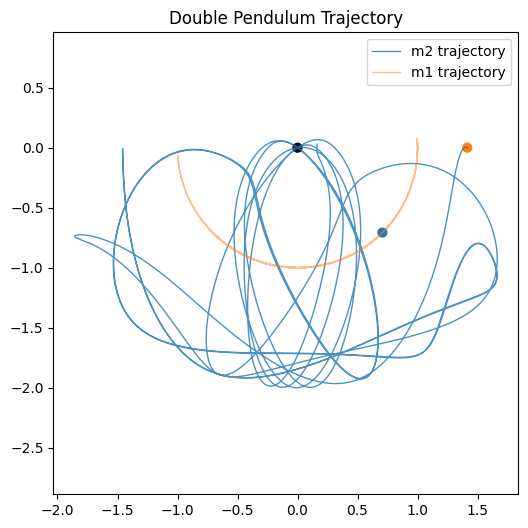

In [20]:
θω_init = QP(jnp.array([0.25*jnp.pi, -1.25*jnp.pi, -.2, 0.5]))
H = gen_Energy()
def H_flat(vec):
    return H(QP(vec))
gradH_flat = grad(H_flat)


AVF_FPI_T = gen_AVF_FPI_T(gradH_flat, config)
trajectory, _, _ = AVF_FPI_T(θω_init)
# out1, out2 , out3 = gen_AVF_NewtonFPI(gradH_flat, config)(θω_init)

x0s = l0*vmap(jnp.sin)(trajectory.q[:,0])
x1s = x0s + l1*vmap(jnp.sin)(trajectory.q[:,1])
y0s = -l0*vmap(jnp.cos)(trajectory.q[:,0])
y1s = y0s-l1*vmap(jnp.cos)(trajectory.q[:,1])

x1s_np = jnp.asarray(x1s)
y1s_np = jnp.asarray(y1s)

x0s_np = jnp.asarray(x0s)
y0s_np = jnp.asarray(y0s)

plt.figure(figsize=(6, 6))

# full trajectory of second mass (most informative)
plt.plot(x1s, y1s, lw=1, alpha=0.8, label="m2 trajectory")

# optional: trajectory of first mass
plt.plot(x0s, y0s, lw=1, alpha=0.5, label="m1 trajectory")

# starting configuration marker
plt.scatter([0, x0s[0], x1s[0]],
            [0, y0s[0], y1s[0]],
            c=["k", "C0", "C1"], s=40)

plt.axis("equal")
plt.legend()
plt.title("Double Pendulum Trajectory")
plt.show()

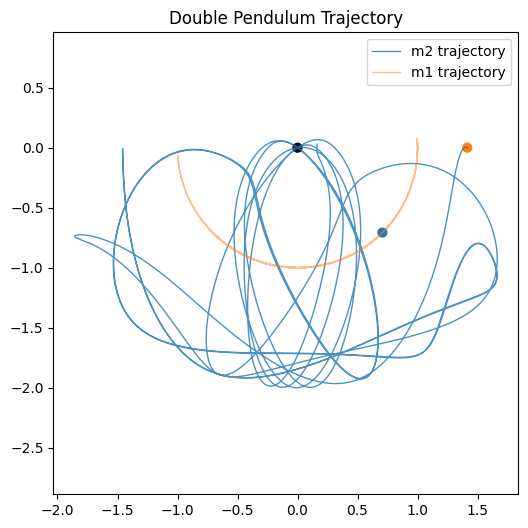

In [95]:
traj_AVF_Newton = b
x0s = l0*vmap(jnp.sin)(traj_AVF_Newton.q[:,0])
x1s = x0s + l1*vmap(jnp.sin)(traj_AVF_Newton.q[:,1])
y0s = -l0*vmap(jnp.cos)(traj_AVF_Newton.q[:,0])
y1s = y0s-l1*vmap(jnp.cos)(traj_AVF_Newton.q[:,1])

x1s_np = jnp.asarray(x1s)
y1s_np = jnp.asarray(y1s)

x0s_np = jnp.asarray(x0s)
y0s_np = jnp.asarray(y0s)

plt.figure(figsize=(6, 6))

# full trajectory of second mass (most informative)
plt.plot(x1s, y1s, lw=1, alpha=0.8, label="m2 trajectory")

# optional: trajectory of first mass
plt.plot(x0s, y0s, lw=1, alpha=0.5, label="m1 trajectory")

# starting configuration marker
plt.scatter([0, x0s[0], x1s[0]],
            [0, y0s[0], y1s[0]],
            c=["k", "C0", "C1"], s=40)

plt.axis("equal")
plt.legend()
plt.title("Double Pendulum Trajectory")
plt.show()

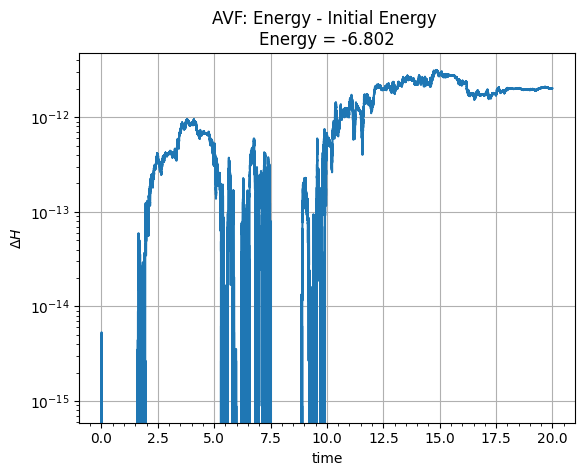

In [99]:
plt.semilogy(ts, vmap(H)(traj_AVF_Newton)-H(θω_init))
plt.title(f'AVF: Energy - Initial Energy \nEnergy = {H(θω_init):0.03f}')
plt.minorticks_on()
plt.xlabel('time')
plt.ylabel('$\Delta H$')
plt.grid(True)

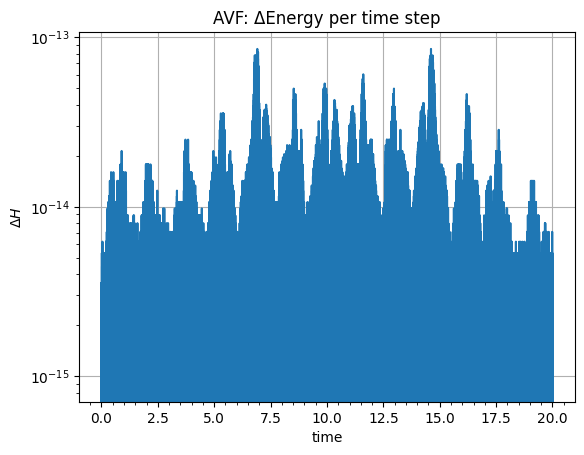

In [173]:
e = np.array(vmap(H)(trajectory))
ediffs = e[1:]-e[0:-1]
y = ediffs
plt.semilogy(ts[:-1], y)
plt.title(f'AVF: ΔEnergy per time step')
plt.minorticks_on()
plt.xlabel('time')
plt.ylabel('$\Delta H$')
plt.grid(True)

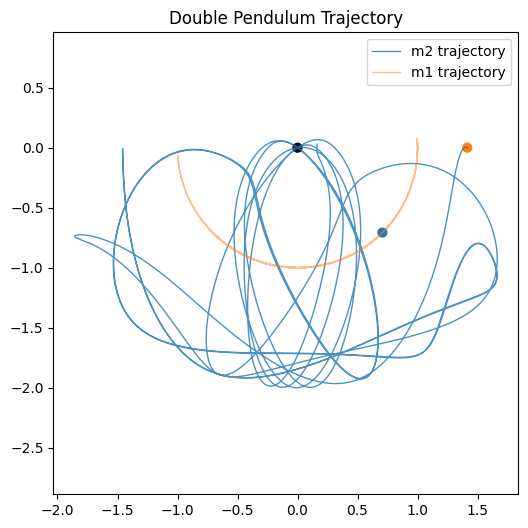

In [180]:
θω_init = QP(jnp.array([0.25*jnp.pi, -1.25*jnp.pi, -.2, 0.5]))
H2 = gen_H2()
def H2_flat(qp_flat):
    return H2(QP(qp_flat))
gradH2 = grad(H2_flat)


AVF_FPI_T = gen_AVF_FPI_T(gradH2, config)
trajectory2, _, _ = AVF_FPI_T(θω_init)

x0s = l0*vmap(jnp.sin)(trajectory2.q[:,0])
x1s = x0s + l1*vmap(jnp.sin)(trajectory2.q[:,1])
y0s = -l0*vmap(jnp.cos)(trajectory2.q[:,0])
y1s = y0s-l1*vmap(jnp.cos)(trajectory2.q[:,1])

x1s_np = jnp.asarray(x1s)
y1s_np = jnp.asarray(y1s)

x0s_np = jnp.asarray(x0s)
y0s_np = jnp.asarray(y0s)

plt.figure(figsize=(6, 6))

# full trajectory of second mass (most informative)
plt.plot(x1s, y1s, lw=1, alpha=0.8, label="m2 trajectory")

# optional: trajectory of first mass
plt.plot(x0s, y0s, lw=1, alpha=0.5, label="m1 trajectory")

# starting configuration marker
plt.scatter([0, x0s[0], x1s[0]],
            [0, y0s[0], y1s[0]],
            c=["k", "C0", "C1"], s=40)

plt.axis("equal")
plt.legend()
plt.title("Double Pendulum Trajectory")
plt.show()

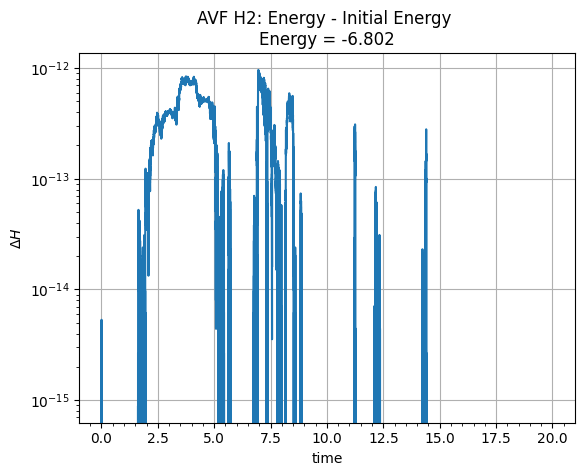

In [181]:
plt.semilogy(ts, vmap(H2)(trajectory2)-H2(θω_init))
plt.title(f'AVF H2: Energy - Initial Energy \nEnergy = {H2(θω_init):0.03f}')
plt.minorticks_on()
plt.xlabel('time')
plt.ylabel('$\Delta H$')
plt.grid(True)

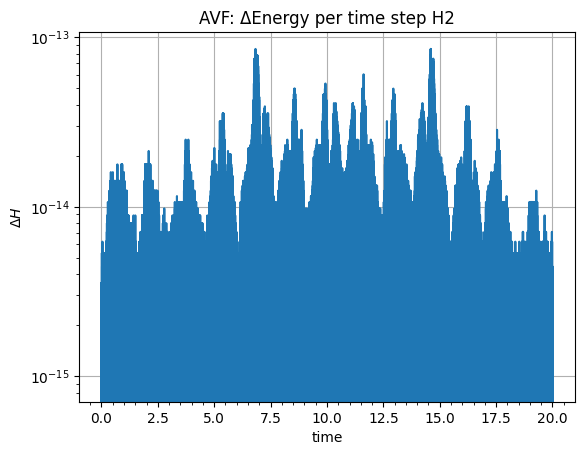

In [183]:
e2 = np.array(vmap(H2)(trajectory2))
ediffs2 = e2[1:]-e2[0:-1]
y = ediffs2
plt.semilogy(ts[:-1], y)
plt.title(f'AVF: ΔEnergy per time step H2')
plt.minorticks_on()
plt.xlabel('time')
plt.ylabel('$\Delta H$')
plt.grid(True)

In [155]:
twos = vmap(H2)(trajectory2)-H2(θω_init) 
ones = vmap(H)(trajectory2)-H(θω_init)
jnp.sum(twos-ones)

Array(-1.06314957e-12, dtype=float64)

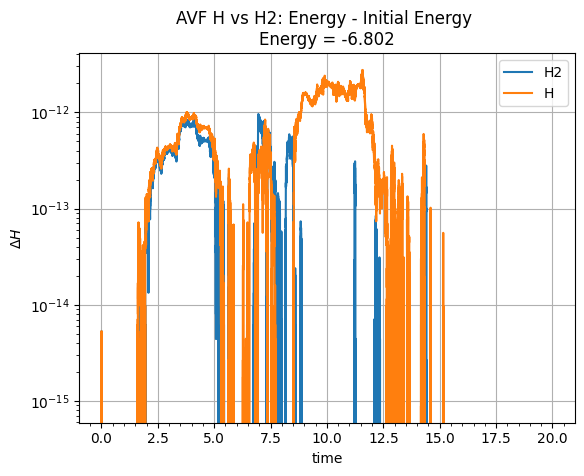

In [184]:
plt.semilogy(ts, vmap(H2)(trajectory2)-H2(θω_init), label='H2')
plt.semilogy(ts, vmap(H)(trajectory)-H(θω_init), label = 'H')
plt.title(f'AVF H vs H2: Energy - Initial Energy \nEnergy = {H(θω_init):0.03f}')
plt.minorticks_on()
plt.xlabel('time')
plt.ylabel('$\Delta H$')
plt.legend()
plt.grid(True)

In [160]:
θω_init = QP.from_array(jnp.array([0.25*jnp.pi, -1.25*jnp.pi, -.2, 0.5]))
H = gen_Energy()
def H_flat(qp_flat):
    return H(QP.from_array(qp_flat))
gradH_flat = grad(H_flat)
AVF_NewtonFPI = gen_AVF_NewtonFPI(gradH_flat, config)
trajectory3 = AVF_NewtonFPI_integrate(θω_init, gradH_flat, config)

x0s = l0*vmap(jnp.sin)(trajectory2.q[:,0])
x1s = x0s + l1*vmap(jnp.sin)(trajectory2.q[:,1])
y0s = -l0*vmap(jnp.cos)(trajectory2.q[:,0])
y1s = y0s-l1*vmap(jnp.cos)(trajectory2.q[:,1])

x1s_np = jnp.asarray(x1s)
y1s_np = jnp.asarray(y1s)

x0s_np = jnp.asarray(x0s)
y0s_np = jnp.asarray(y0s)

plt.figure(figsize=(6, 6))

# full trajectory of second mass (most informative)
plt.plot(x1s, y1s, lw=1, alpha=0.8, label="m2 trajectory")

# optional: trajectory of first mass
plt.plot(x0s, y0s, lw=1, alpha=0.5, label="m1 trajectory")

# starting configuration marker
plt.scatter([0, x0s[0], x1s[0]],
            [0, y0s[0], y1s[0]],
            c=["k", "C0", "C1"], s=40)

plt.axis("equal")
plt.legend()
plt.title("Double Pendulum Trajectory")
plt.show()

AttributeError: DynamicJaxprTracer has no attribute to_array